# Model Training & Comparison
### Random Forest vs XGBoost vs SVM

Trains 3 classifiers on the crop recommendation dataset, compares performance,
and saves the best one for use in the Streamlit app.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
from xgboost import XGBClassifier

sns.set_style('whitegrid')

In [2]:
df = pd.read_csv('../data/Crop_recommendation.csv')
df.head()

,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


## 1. Train/Test Split

In [3]:
X = df[['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']]
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Train size: {X_train.shape[0]}, Test size: {X_test.shape[0]}')

Train size: 1760, Test size: 440


## 2. Train Models

SVM needs scaled features; tree-based models (RF, XGBoost) don't.

In [4]:
# --- Random Forest ---
rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)
rf_preds = rf.predict(X_test)
rf_acc = accuracy_score(y_test, rf_preds)
rf_f1 = f1_score(y_test, rf_preds, average='weighted')
print(f'Random Forest -> Accuracy: {rf_acc:.4f}, F1: {rf_f1:.4f}')

Random Forest -> Accuracy: 0.9955, F1: 0.9955


In [5]:
# --- XGBoost (needs numeric-encoded labels) ---
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)

xgb = XGBClassifier(n_estimators=200, use_label_encoder=False, eval_metric='mlogloss', random_state=42)
xgb.fit(X_train, y_train_enc)
xgb_preds_enc = xgb.predict(X_test)
xgb_preds = le.inverse_transform(xgb_preds_enc)
xgb_acc = accuracy_score(y_test, xgb_preds)
xgb_f1 = f1_score(y_test, xgb_preds, average='weighted')
print(f'XGBoost -> Accuracy: {xgb_acc:.4f}, F1: {xgb_f1:.4f}')

d:\projects\crop-rotation-recommender\venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [11:51:53] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:794: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost -> Accuracy: 0.9886, F1: 0.9886


In [6]:
# --- SVM (scaled features) ---
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

svm = SVC(kernel='rbf', probability=True, random_state=42)
svm.fit(X_train_scaled, y_train)
svm_preds = svm.predict(X_test_scaled)
svm_acc = accuracy_score(y_test, svm_preds)
svm_f1 = f1_score(y_test, svm_preds, average='weighted')
print(f'SVM -> Accuracy: {svm_acc:.4f}, F1: {svm_f1:.4f}')

d:\projects\crop-rotation-recommender\venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


SVM -> Accuracy: 0.9841, F1: 0.9840


## 3. Compare Models

           Model  Accuracy  F1 Score
0  Random Forest  0.995455  0.995452
1        XGBoost  0.988636  0.988559
2            SVM  0.984091  0.984038


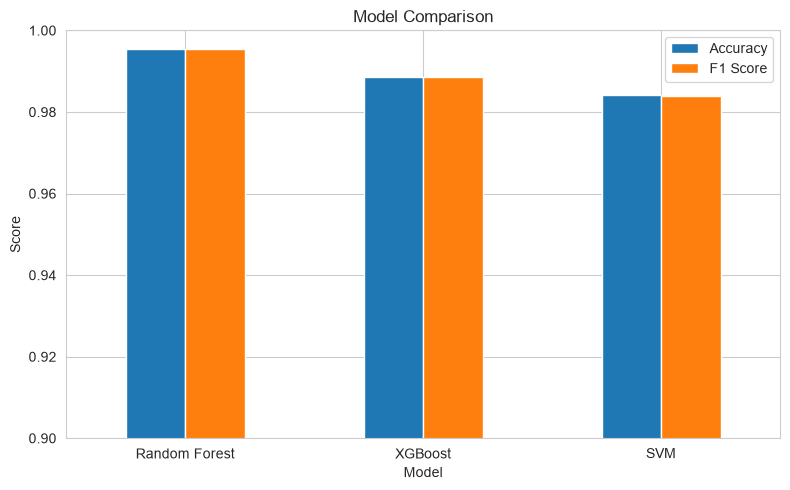

In [7]:
results = pd.DataFrame({
    'Model': ['Random Forest', 'XGBoost', 'SVM'],
    'Accuracy': [rf_acc, xgb_acc, svm_acc],
    'F1 Score': [rf_f1, xgb_f1, svm_f1]
})
print(results)

results.set_index('Model')[['Accuracy', 'F1 Score']].plot(kind='bar', figsize=(8,5), ylim=(0.9,1.0))
plt.title('Model Comparison')
plt.ylabel('Score')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('../report/model_comparison.png', dpi=150)
plt.show()

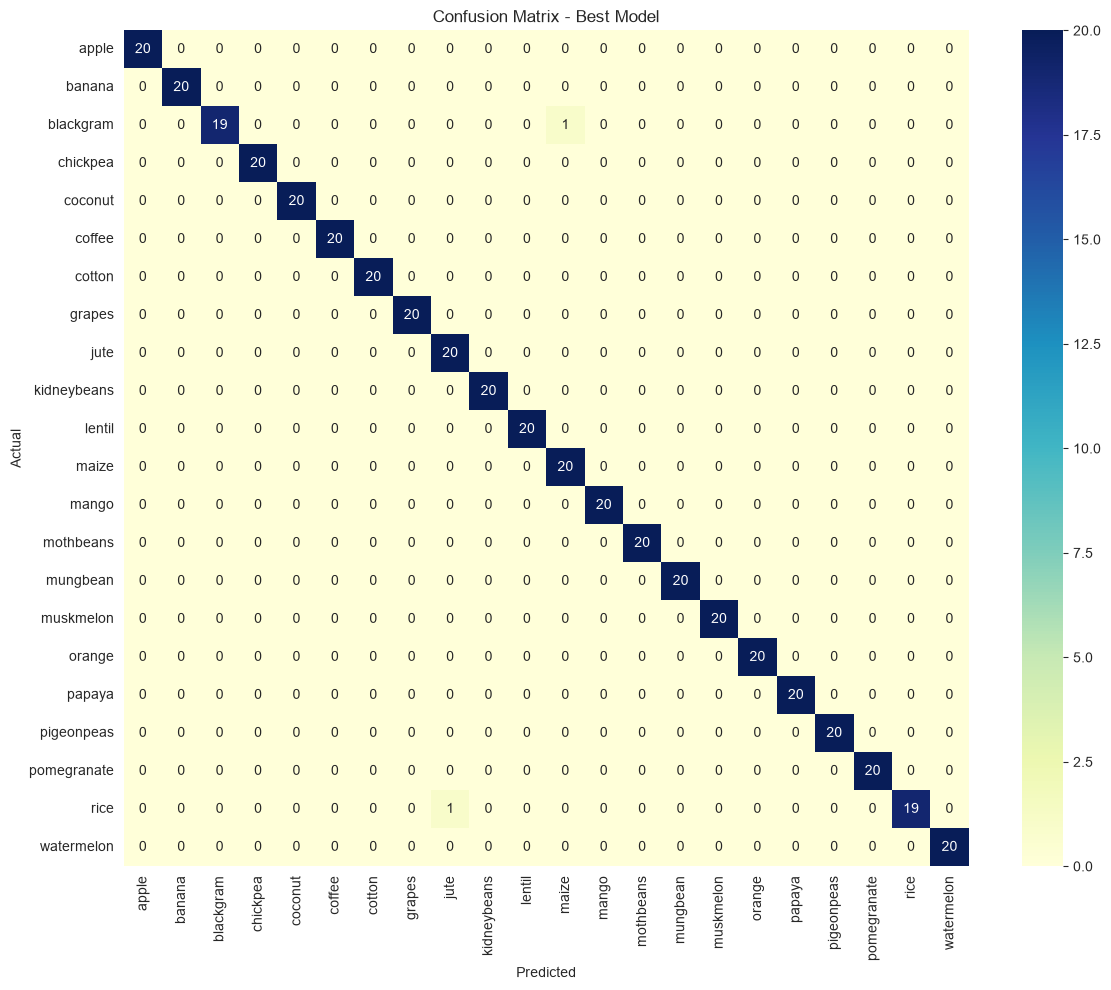

In [8]:
# Confusion matrix for the best model (adjust variable name based on results above)
best_preds = rf_preds  # change to xgb_preds or svm_preds if that one wins

cm = confusion_matrix(y_test, best_preds, labels=sorted(y.unique()))
plt.figure(figsize=(12,10))
sns.heatmap(cm, annot=True, fmt='d', cmap='YlGnBu',
            xticklabels=sorted(y.unique()), yticklabels=sorted(y.unique()))
plt.title('Confusion Matrix - Best Model')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('../report/confusion_matrix.png', dpi=150)
plt.show()

## 4. Feature Importance (Random Forest)

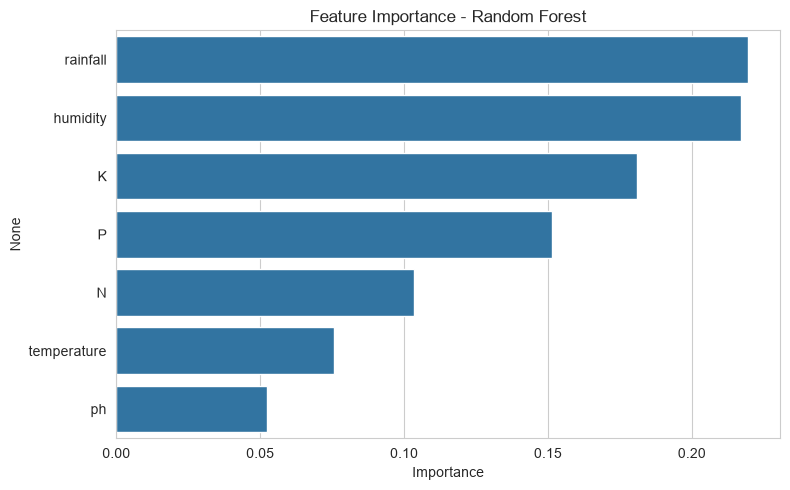

rainfall       0.219641
humidity       0.217058
K              0.180813
P              0.151342
N              0.103356
temperature    0.075485
ph             0.052305
dtype: float64

In [9]:
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
plt.figure(figsize=(8,5))
sns.barplot(x=importances.values, y=importances.index)
plt.title('Feature Importance - Random Forest')
plt.xlabel('Importance')
plt.tight_layout()
plt.savefig('../report/feature_importance.png', dpi=150)
plt.show()

importances

## 5. Save Best Model

This saves the model the Streamlit app (`app/app.py`) will load.
Random Forest is used by default below since it needs no scaling step,
which keeps the app simpler. Switch to `svm`/`scaler` or `xgb`/`le` if one
of those wins in your comparison -- just remember the app will need updating
to match (SVM needs the scaler applied to inputs; XGBoost needs the label encoder).

In [10]:
joblib.dump(rf, 'crop_model.pkl')
print('Saved crop_model.pkl -- ready for the Streamlit app.')

Saved crop_model.pkl -- ready for the Streamlit app.


## 6. Full Rotation Metadata (all 22 crops)

Copy this dictionary into `app/app.py` (replacing the partial one there) so every
crop in the dataset has rotation rules, not just a subset.

In [11]:
crop_metadata = {
    'rice':        {'family': 'cereal',    'nitrogen_effect': 'depleting'},
    'maize':       {'family': 'cereal',    'nitrogen_effect': 'depleting'},
    'chickpea':    {'family': 'legume',    'nitrogen_effect': 'fixing'},
    'kidneybeans': {'family': 'legume',    'nitrogen_effect': 'fixing'},
    'pigeonpeas':  {'family': 'legume',    'nitrogen_effect': 'fixing'},
    'mothbeans':   {'family': 'legume',    'nitrogen_effect': 'fixing'},
    'mungbean':    {'family': 'legume',    'nitrogen_effect': 'fixing'},
    'blackgram':   {'family': 'legume',    'nitrogen_effect': 'fixing'},
    'lentil':      {'family': 'legume',    'nitrogen_effect': 'fixing'},
    'pomegranate': {'family': 'fruit_tree','nitrogen_effect': 'neutral'},
    'banana':      {'family': 'fruit_tree','nitrogen_effect': 'depleting'},
    'mango':       {'family': 'fruit_tree','nitrogen_effect': 'neutral'},
    'grapes':      {'family': 'fruit_vine','nitrogen_effect': 'neutral'},
    'watermelon':  {'family': 'cucurbit',  'nitrogen_effect': 'depleting'},
    'muskmelon':   {'family': 'cucurbit',  'nitrogen_effect': 'depleting'},
    'apple':       {'family': 'fruit_tree','nitrogen_effect': 'neutral'},
    'orange':      {'family': 'fruit_tree','nitrogen_effect': 'neutral'},
    'papaya':      {'family': 'fruit_tree','nitrogen_effect': 'neutral'},
    'coconut':     {'family': 'palm',      'nitrogen_effect': 'neutral'},
    'cotton':      {'family': 'fiber',     'nitrogen_effect': 'depleting'},
    'jute':        {'family': 'fiber',     'nitrogen_effect': 'neutral'},
    'coffee':      {'family': 'shrub',     'nitrogen_effect': 'neutral'},
}

assert set(crop_metadata.keys()) == set(df['label'].unique()), 'Mismatch with dataset labels!'
print('All 22 crops mapped successfully.')

All 22 crops mapped successfully.
